# Energy Regression example in the Aleph simulated data

### Data:
The input variables (X) are (where Aleph uses only the first six):
* **prob_b**: Probability of being a b-jet from the pointing of the tracks to the vertex.
* **spheri**: Sphericity of the event, i.e. how spherical it is.
* **pt2rel**: The transverse momentum squared of the tracks relative to the jet axis, i.e. width of the jet.
* **multip**: Multiplicity of the jet (in a relative measure).
* **bqvjet**: b-quark vertex of the jet, i.e. the probability of a detached vertex.
* **ptlrel**: Transverse momentum (in GeV) of possible lepton with respect to jet axis (about 0 if no leptons).
* energy: Measured energy of the jet in GeV. Should be 45 GeV, but fluctuates.
* cTheta: cos(theta), i.e. the polar angle of the jet with respect to the beam axis. Note, that the detector works best in the central region (|cTheta| small) and less well in the forward regions.
* phi:    The azimuth angle of the jet. As the detector is uniform in phi, this should not matter (much).
* isb:    1 if it is from a b-quark and 0, if it is not.
* nnbjet: Value of original Aleph b-jet tagging algorithm, using only the last six variables (for reference).


### Task:
Thus, the task before you is to produce functions (non-ML and then ML algorithm), which given the input variables X provides an output variable estimate, y_pred, which is "closest possible" to the target variable, y. The "closest possible" is left to the user to define in a _Loss Function_. 

* Author: Arnau Morancho Tardà (NBI) and Rasmus Ørsøe (NBI)
* Email:  arnau.morancho@nbi.ku.dk
* Date:   4th of May 2026

In [149]:
from __future__ import print_function, division   # Ensures Python3 printing & division standard
from matplotlib import pyplot as plt
from matplotlib import colors
from matplotlib.colors import LogNorm
import numpy as np
import csv

import time


Possible other packages to consider: cornerplot, seaplot, sklearn.decomposition(PCA)

In [150]:
r = np.random
r.seed(42)

SavePlots = False
plt.close('all')

# Read the data

We choose input and target variables:

* 'energy', 'cTheta', and 'phi' are kinematic variables of the jet, and not about the jet type.
   They are good variables for using regression algorithms. In particular, we will predict the energy, which is not cyclic and therefore less considerations need to take into account. We encourage you trying or thinking about how to solve the cyclic problem for 'cTheta' and 'phi'.

Usually one would apply further checks/regularization/standardization of data at this step, but this data has already been "prepared", so we'll move onto seperate the data into input and truth:

In [151]:
#We import the data slightly more convenient here
import pandas as pd 
from pandas import Series, DataFrame 

# Read the data in using Pandas Dataframe and print the variables:
data = pd.DataFrame(np.genfromtxt('../../Week1/AlephBtag_MC_train_Nev5000.csv', names=True))
#data = pd.DataFrame(np.genfromtxt('AlephBtag_MC_train_Nev50000.csv', names=True))

variables = data.columns
print(variables)

# Decide on which variables to use for input (X) and what defines the label (Y):
input_variables = variables[(variables != 'nnbjet') & (variables != 'isb') & (variables != 'energy') & (variables != 'cTheta') & (variables != 'phi')]
input_data      = data[input_variables]
truth_data      = data['energy']
print("  Variables used for training: ", input_variables)

Index(['energy', 'cTheta', 'phi', 'prob_b', 'spheri', 'pt2rel', 'multip',
       'bqvjet', 'ptlrel', 'nnbjet', 'isb'],
      dtype='object')
  Variables used for training:  Index(['prob_b', 'spheri', 'pt2rel', 'multip', 'bqvjet', 'ptlrel'], dtype='object')


***

# Regression using LightGBM:

This is a solution example using LightGBM (tree based).

In [152]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import confusion_matrix
import lightgbm as lgb
from lightgbm import early_stopping
from scipy.stats import gaussian_kde

In [153]:
X_train, X_test, y_train, y_test = train_test_split(input_data, truth_data, test_size=0.25, random_state=42)

In [154]:
lgb_train = lgb.Dataset(X_train, y_train)
lgb_eval  = lgb.Dataset(X_test,  y_test, reference=lgb_train)
params = {
    'boosting_type': 'gbdt', # Traditional Gradient Boosting tree, we are combining many 'weak' learners here!
    'objective': 'regression',   # The outcome is binary, b-quark or not
    'num_leaves': 10,         # Set a maximum tree leaves to avoid overfitting
    'learning_rate': 0.03,
    'verbose':-1,            # Suppress some output
}

# Train the model:
gbm = lgb.train(params,
                lgb_train,
                num_boost_round=1000,
                valid_sets=lgb_eval,
                callbacks=[early_stopping(40)])     # Stops if no improvement is seen in N rounds.

Training until validation scores don't improve for 40 rounds
Early stopping, best iteration is:
[535]	valid_0's l2: 27.3787


In [155]:
# Make predictions:
y_pred_lgbm = gbm.predict(X_test)  # Scores are floats in the range ]0,1[.
# accuracy check
mse = mean_squared_error(y_test, y_pred_lgbm)
rmse = mse**(0.5)
print("MSE: %.2f" % mse)
print("RMSE: %.2f" % rmse)

MSE: 27.38
RMSE: 5.23


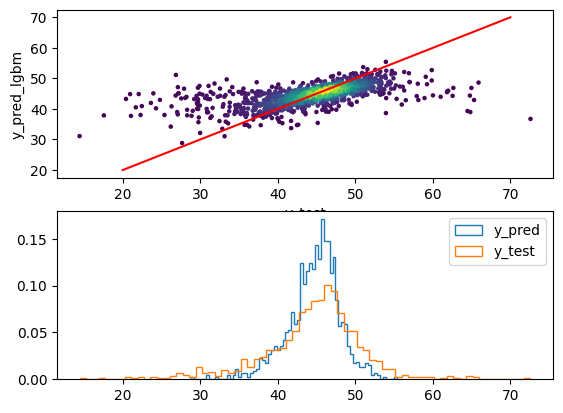

In [156]:
x = np.linspace(20,70,100)
y = x

# Calculate the point density
xy = np.vstack([y_test,y_pred_lgbm])
z = gaussian_kde(xy)(xy)

fig, axs = plt.subplots(2)
axs[0].scatter(y_test,y_pred_lgbm, c=z, s=5)
axs[0].plot(x, y, '-r')
axs[0].set_xlabel('y_test')
axs[0].set_ylabel('y_pred_lgbm')
axs[1].hist(y_pred_lgbm, alpha=1 ,histtype='step', density=True, bins=70, label='y_pred')
axs[1].hist(y_test,alpha=1 ,histtype='step', density=True, bins=70, label='y_test')
axs[1].legend()

## Optimization LightGBM

### Random Search

In [157]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score
from scipy.stats import randint, poisson,uniform
import random

In [158]:
gbm = lgb.LGBMRegressor()
# specify parameters and distributions to sample from
parameters_RandomSearch = {'learning_rate': list(np.logspace(np.log10(0.005), np.log10(0.5), base= 10, num=1000)),#random.uniform(1e-6, 1e-3),
                           'num_leaves': poisson(50),
                           'max_depth': randint(1, 50), 
                           'n_estimators' : poisson(500), 
                           #'learning_rate': uniform(),
                          }

In [159]:
# run randomized search
n_iter_search = 20
RandomSearch = RandomizedSearchCV(gbm, 
                                  param_distributions=parameters_RandomSearch, 
                                  n_iter=n_iter_search, 
                                  #scoring = 'neg_mean_absolute_error',
                                  cv=5, 
                                  return_train_score=True,
                                  random_state=42,
                                 )

In [160]:
# fit the random search instance
RandomSearch.fit(X_train, y_train);

In [161]:
RandomSearch_results = pd.DataFrame(RandomSearch.cv_results_)                 
print("Random Search: \tBest parameters: ", RandomSearch.best_params_, f", Best scores: {RandomSearch.best_score_:.3f}")

Random Search: 	Best parameters:  {'learning_rate': np.float64(0.0080015515686935), 'max_depth': 29, 'n_estimators': 477, 'num_leaves': 52} , Best scores: 0.319


In [162]:
RandomSearch_results.head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_learning_rate,param_max_depth,param_n_estimators,param_num_leaves,params,split0_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.267892,0.003527,0.008039,0.000189,0.008002,29,477,52,"{'learning_rate': 0.0080015515686935, 'max_dep...",0.327811,...,0.318619,0.025473,1,0.598594,0.617153,0.625371,0.617848,0.617428,0.615279,0.008888
1,0.203213,0.005229,0.007586,0.000574,0.013409,11,497,41,"{'learning_rate': 0.013409063047265076, 'max_d...",0.319200,...,0.314340,0.025799,3,0.618859,0.647671,0.652751,0.646276,0.649067,0.642925,0.012224
2,0.032626,0.001056,0.002910,0.000195,0.020682,2,508,50,"{'learning_rate': 0.020681718420316363, 'max_d...",0.265225,...,0.257827,0.018190,13,0.306856,0.336136,0.330224,0.326599,0.333532,0.326669,0.010411
3,0.235645,0.012567,0.009918,0.000653,0.044660,16,481,52,"{'learning_rate': 0.04466022999290484, 'max_de...",0.289047,...,0.276242,0.017636,8,0.882498,0.897703,0.894685,0.890180,0.890406,0.891094,0.005134
4,0.046850,0.000982,0.003670,0.000076,0.015327,3,528,49,"{'learning_rate': 0.015326976475282632, 'max_d...",0.271966,...,0.274578,0.024475,9,0.356188,0.380704,0.389837,0.384978,0.378334,0.378008,0.011593
5,0.191347,0.003845,0.008569,0.000712,0.079464,14,522,39,"{'learning_rate': 0.07946414328114888, 'max_de...",0.254264,...,0.240184,0.020386,16,0.934543,0.942230,0.940206,0.936288,0.938450,0.938343,0.002730
6,0.130985,0.004843,0.006017,0.000571,0.027021,7,507,42,"{'learning_rate': 0.027021082103529572, 'max_d...",0.314552,...,0.302658,0.025873,5,0.674539,0.688595,0.683044,0.677779,0.699464,0.684684,0.008798
7,0.235767,0.017331,0.010321,0.001448,0.066389,40,517,43,"{'learning_rate': 0.06638854146777148, 'max_de...",0.261881,...,0.248067,0.015040,15,0.936318,0.942992,0.942493,0.940398,0.941043,0.940649,0.002361
8,0.392826,0.011165,0.016710,0.001118,0.044867,18,533,62,"{'learning_rate': 0.04486657907291759, 'max_de...",0.279093,...,0.267206,0.020645,11,0.924195,0.935546,0.930316,0.930252,0.931745,0.930411,0.003656
9,0.409568,0.044875,0.015250,0.002067,0.142044,40,526,51,"{'learning_rate': 0.14204418450916512, 'max_de...",0.217265,...,0.200188,0.013073,19,0.995452,0.996062,0.995820,0.995427,0.995636,0.995679,0.000238


In [163]:
clf_RandomSearch = RandomSearch.best_estimator_


# Make predictions:
y_pred_lgbm_rand_opt = clf_RandomSearch.predict(X_test)  # Scores are floats in the range ]0,1[.
# accuracy check
mse_lgb_rand_opt = mean_squared_error(y_test, y_pred_lgbm_rand_opt)
rmse_lgb_rand_opt = mse_lgb_rand_opt**(0.5)

print(f'RMSE LightGBM no optimization: {rmse:.4f}')
print(f'RMSE LightGBM Random Search: {rmse_lgb_rand_opt:.4f}')

RMSE LightGBM no optimization: 5.2325
RMSE LightGBM Random Search: 5.1717


***

# Regression using TensorFlow:

This is a solution example using TensorFlow (NN based).


In [164]:
import tensorflow as tf
from keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import QuantileTransformer
#from keras.wrappers.scikit_learn import KerasClassifier, KerasRegressor # deprecated
from scikeras.wrappers import KerasClassifier, KerasRegressor # pip install scikeras
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization
import torch
from keras.optimizers import Adam  

In [165]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')  #Use GPU

Something important for neural networks is that all the input data should be normalized or standarized. As mentioned before all the input data is already prepared but the output (energy) is not. So as an example we show one way of using one of this transorfations (QuantileTransformer). After we have predict our target we can do the inverse transformation to get the expected scale. 


In [166]:
qt = QuantileTransformer(n_quantiles=10, random_state=0)
y_norm = qt.fit_transform(truth_data.array.reshape(-1, 1))
X_train, X_test, y_train, y_test = train_test_split(input_data, y_norm, test_size=0.25, random_state=42)

In [167]:
# set up the network hyperparameters
n_inputs = 6
n_hidden1 = 10
n_hidden2 = 10
n_hidden3 = 10
n_outputs = 1
batch_norm_momentum = 0.9
#learning_rate = 0.001 # adam optimizer adapts the value of the learning rate
init = tf.keras.initializers.VarianceScaling(scale=1.0, mode='fan_in')
#centropy = tf.keras.losses.BinaryCrossentropy() #good for categorical data SparseCategoricalCrossentropy(from_logits=True)

# network structure
def base_model():
    nn_reg = tf.keras.models.Sequential([
      Input(shape=(n_inputs,)),
      Dense(units=n_inputs, kernel_initializer='normal', activation='relu'),
      Dense(n_hidden1, activation='relu', kernel_initializer='normal'),
      BatchNormalization(momentum=batch_norm_momentum, center=True, scale=True),
      Dense(n_hidden2, activation='relu', kernel_initializer='normal'),
      BatchNormalization(momentum=batch_norm_momentum, center=True, scale=True),
      Dense(n_hidden3, activation='relu', kernel_initializer='normal'),
      BatchNormalization(momentum=batch_norm_momentum, center=True, scale=True),
      Dense(n_outputs, kernel_initializer='normal')
    ])
    
    nn_reg.compile(loss='mean_squared_error', optimizer='adam')#, metrics=['accuracy'])
#log_cosh
    return nn_reg

n_epochs = 30
batch_size = 300

clf = KerasRegressor(model=base_model, epochs=n_epochs, batch_size=batch_size ,verbose=0)    
history = clf.fit(X=(X_train),y=(y_train), validation_data=(np.array(X_test), np.array(y_test)))

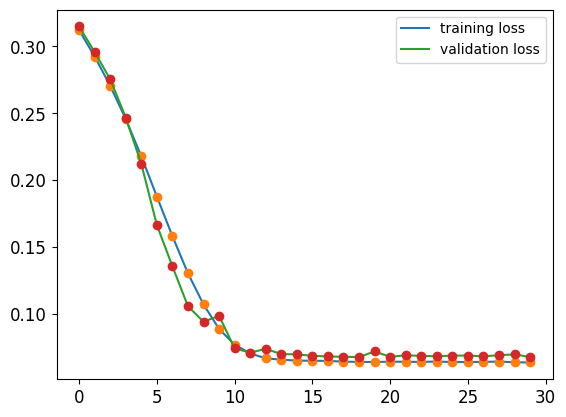

In [168]:
training_loss = history.history_['loss']
validation_loss = history.history_['val_loss']

fig =  plt.figure()
plt.plot(training_loss,label = 'training loss')
plt.plot(training_loss,'o')
plt.plot(validation_loss, label = 'validation loss')
plt.plot(validation_loss, 'o')
plt.legend()
plt.xticks(size = 12)
plt.yticks(size = 12)
plt.show()

In [169]:
y_pred_tf_norm = clf.predict(X_test)

#Renormalize
y_pred_tf = qt.inverse_transform(y_pred_tf_norm.reshape(-1, 1))
y_test_tf = qt.inverse_transform(y_test.reshape(-1, 1))

In [170]:
# accuracy check
mse_tf = mean_squared_error(y_test_tf, y_pred_tf)
rmse_tf = mse_tf**(0.5) 

print(f'RMSE LightGBM no optimization: {rmse:.4f}')
print(f'RMSE LightGBM Random Search: {rmse_lgb_rand_opt:.4f}')
print(f'RMSE TensorFlow no optimization: {rmse_tf:.4f}')

RMSE LightGBM no optimization: 5.2325
RMSE LightGBM Random Search: 5.1717
RMSE TensorFlow no optimization: 6.1100


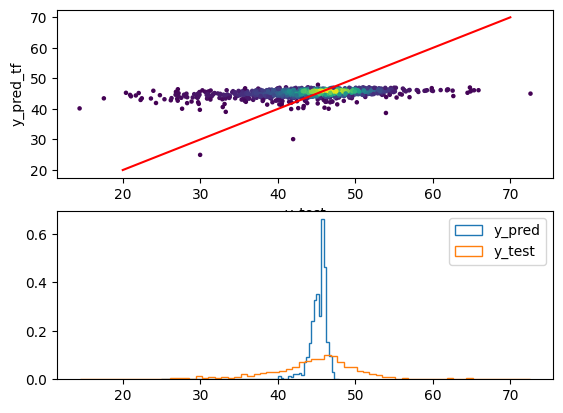

In [171]:
x = np.linspace(20,70,100)
y = x

# Calculate the point density
xy = np.vstack([y_test_tf.reshape(-1),y_pred_tf.reshape(-1)])
z = gaussian_kde(xy)(xy)


fig, axs = plt.subplots(2)
axs[0].scatter(y_test_tf,y_pred_tf, c=z, s=5)
axs[0].plot(x, y, '-r')
axs[0].set_xlabel('y_test')
axs[0].set_ylabel('y_pred_tf')
axs[1].hist(y_pred_tf, alpha=1 ,histtype='step', density=True, bins=70, label='y_pred')
axs[1].hist(y_test_tf,alpha=1 ,histtype='step', density=True, bins=70, label='y_test')
axs[1].legend()


## Optimize TensorFlow using Random search

In [172]:
from sklearn.model_selection import RandomizedSearchCV

In [173]:
# specify parameters and distributions to sample from
parameters_RandomSearch = {"epochs": randint(10, 60), 
                           "batch_size": randint(100,2000),
                           #"n_hidden1": (10,500),
                           #"n_hidden2": (10,500),
                           #"n_hidden3": (10,500),
                          }

In [174]:
# run randomized search
n_iter_search = 9
RandomSearch_tf = RandomizedSearchCV(clf, 
                                  param_distributions=parameters_RandomSearch, 
                                  n_iter=n_iter_search, 
                                  cv=5, 
                                  return_train_score=True,
                                  random_state=42,
                                 )

In [175]:
# fit the random search instance
# This part fails with newer versions of scikit-learn because scikeras hasn't kept up with scikit-learn.
# There is no easy code fix to make it compatibe, the easiest is to downgrade scikit-learn: pip install "scikit-learn==1.5.2"
RandomSearch_tf.fit(X_train, y_train);

In [176]:
RandomSearch_results_tf = pd.DataFrame(RandomSearch_tf.cv_results_)                 
print("Random Search: \tBest parameters: ", RandomSearch_tf.best_params_, f", Best scores: {RandomSearch_tf.best_score_:.3f}")

Random Search: 	Best parameters:  {'batch_size': 230, 'epochs': 31} , Best scores: 0.091


In [177]:
tf_RandomSearch = RandomSearch_tf.best_estimator_
# Make predictions:
y_pred_tf_rand_opt_norm = tf_RandomSearch.predict(X_test)  

#Renormalize
y_pred_tf_rand_opt = qt.inverse_transform(y_pred_tf_rand_opt_norm.reshape(-1, 1))

# accuracy check
mse_tf_rand_opt = mean_squared_error(y_test_tf, y_pred_tf_rand_opt)
rmse_tf_rand_opt = mse_tf_rand_opt**(0.5)

print(f'RMSE LightGBM no optimization: {rmse:.4f}')
print(f'RMSE LightGBM Random Search: {rmse_lgb_rand_opt:.4f}')
print(f'RMSE TensorFlow no optimization: {rmse_tf:.4f}')
print(f'RMSE TensorFlow Random Search: {rmse_tf_rand_opt:.4f}')

RMSE LightGBM no optimization: 5.2325
RMSE LightGBM Random Search: 5.1717
RMSE TensorFlow no optimization: 6.1100
RMSE TensorFlow Random Search: 6.2877


## Optimize TensorFlow using Bayesian Optimization

In [178]:
from bayes_opt import BayesianOptimization
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer
#from ExternalFunctions import optimize_nn,mean_rel_err_rate

def mean_rel_err_rate(truth,pred):
    return ( np.abs(pred-truth)/truth ).mean()
def TensorFlow_CrossValidation(n_hidden1,n_hidden2,n_hidden3,n_epochs,batch_size,data,targets,cv=5,metric='mean_absolute_error'):
    """
       Fits a TensorFlow with the given paramaters to the target 
       given data, calculated a CV accuracy score and returns the mean.
       The goal is to find combinations of max_depth, min_samples_leaf 
       that maximize the accuracy
    """
    own_scorer = make_scorer(mean_rel_err_rate, greater_is_better=False)
    estimator = KerasRegressor(model=base_model, epochs=n_epochs, batch_size=batch_size,verbose=0)  
    cval = cross_val_score(estimator,data,targets,scoring=own_scorer,cv=cv)
   
    return -cval.mean()

In [179]:
def optimize_TensorFlow(data, targets, pars, n_iter,metric='mean_absolute_error',cv=5):
    """Apply Bayesian Optimization to TensorFlow parameters."""
    
    def crossval_wrapper(n_hidden1,n_hidden2,n_hidden3,n_epochs,batch_size):
        """Wrapper of TensorFlow cross validation. 
           Notice how we ensure max_depth, min_samples_leaf 
           are casted to integer before we pass them along.
        """
        return TensorFlow_CrossValidation(n_hidden1=int(n_hidden1),n_hidden2=int(n_hidden2),n_hidden3=int(n_hidden3),
                                  n_epochs=int(n_epochs),
                                  batch_size=int(batch_size),
                                  data=data,targets=targets,cv=cv,metric=metric)

    optimizer = BayesianOptimization(f=crossval_wrapper, 
                                     pbounds=pars, 
                                     random_state=42, 
                                     verbose=2)
    optimizer.maximize(init_points=5, n_iter=int(n_iter))

    return optimizer

In [180]:
parameters_BayesianOptimization = {"n_epochs": (10,60), 
                                   "batch_size": (100,2000),
                                   "n_hidden1": (10,500),
                                   "n_hidden2": (10,500),
                                   "n_hidden3": (10,500),}

#BayesianOptimization = optimize_nn(X_train_r,y_train,parameters_BayesianOptimization)
BayesianOptimization = optimize_TensorFlow(X_train, 
                                             y_train, 
                                             parameters_BayesianOptimization, 
                                             n_iter=5)
print(BayesianOptimization.max)

|   iter    |  target   | n_epochs  | batch_... | n_hidden1 | n_hidden2 | n_hidden3 |
-------------------------------------------------------------------------------------
| 1         | 0.6612229 | 28.727005 | 1906.3571 | 368.67703 | 303.34265 | 86.449133 |
| 2         | 0.9338503 | 17.799726 | 210.35886 | 434.42631 | 304.54635 | 356.95556 |
| 3         | 0.8793073 | 11.029224 | 1942.8287 | 417.89689 | 114.04616 | 99.094233 |
| 4         | 0.6970202 | 19.170225 | 678.06026 | 267.13065 | 221.65305 | 152.70227 |
| 5         | 0.8750244 | 40.592644 | 365.03833 | 153.15087 | 189.51730 | 233.47429 |
| 6         | 0.9104116 | 40.377242 | 110.14436 | 394.86806 | 319.50369 | 230.85466 |
| 7         | 0.9209759 | 25.010778 | 218.87526 | 334.43699 | 281.35327 | 285.59599 |
| 8         | 0.6401661 | 32.793491 | 1557.2252 | 264.31304 | 69.302190 | 48.414845 |
| 9         | 0.8347310 | 57.337042 | 109.53965 | 382.10204 | 86.378743 | 409.73882 |
| 10        | 0.9057153 | 60.0      | 169.91742 | 312.

In [189]:
# set up the network hyperparameters
n_inputs = 6
n_hidden1 = 267
n_hidden2 = 221
n_hidden3 = 152
n_outputs = 1
batch_norm_momentum = 0.9
#learning_rate = 0.001 # adam optimizer adapts the value of the learning rate
init = tf.keras.initializers.VarianceScaling(scale=1.0, mode='fan_in')
#centropy = tf.keras.losses.BinaryCrossentropy() #good for categorical data SparseCategoricalCrossentropy(from_logits=True)

# network structure
def base_model_opt():
    nn_reg = tf.keras.models.Sequential([
      Input(shape=(n_inputs,)),
      Dense(units=n_inputs, kernel_initializer='normal', activation='relu'),
      Dense(n_hidden1, activation='relu', kernel_initializer='normal'),
      BatchNormalization(momentum=batch_norm_momentum, center=True, scale=True),
      Dense(n_hidden2, activation='relu', kernel_initializer='normal'),
      BatchNormalization(momentum=batch_norm_momentum, center=True, scale=True),
      Dense(n_hidden3, activation='relu', kernel_initializer='normal'),
      BatchNormalization(momentum=batch_norm_momentum, center=True, scale=True),
      Dense(n_outputs, kernel_initializer='normal')
    ])
    
    nn_reg.compile(loss='mean_squared_error', optimizer='adam')#, metrics=['accuracy'])
#log_cosh
    return nn_reg

n_epochs = 25
batch_size = 448

clf = KerasRegressor(model=base_model_opt, epochs=n_epochs, batch_size=batch_size ,verbose=0)    
history = clf.fit(X=(X_train),y=(y_train), validation_data=(np.array(X_test), np.array(y_test)))

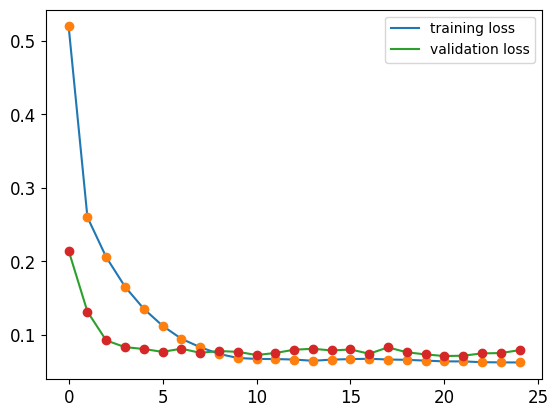

In [190]:
training_loss = history.history_['loss']
validation_loss = history.history_['val_loss']

fig =  plt.figure()
plt.plot(training_loss,label = 'training loss')
plt.plot(training_loss,'o')
plt.plot(validation_loss, label = 'validation loss')
plt.plot(validation_loss, 'o')
plt.legend()
plt.xticks(size = 12)
plt.yticks(size = 12)
plt.show()

In [191]:
y_pred_tf_norm_bay_opt = clf.predict(X_test)

#Renormalize
y_pred_tf_bay_opt = qt.inverse_transform(y_pred_tf_norm_bay_opt.reshape(-1, 1))

In [192]:
# accuracy check
mse_tf_bay_opt = mean_squared_error(y_test_tf, y_pred_tf_bay_opt)
rmse_tf_bay_opt = mse_tf_bay_opt**(0.5) 

print(f'RMSE LightGBM no optimization: {rmse:.4f}')
print(f'RMSE LightGBM Random Search: {rmse_lgb_rand_opt:.4f}')
print(f'RMSE TensorFlow no optimization: {rmse_tf:.4f}')
print(f'RMSE TensorFlow Random Search: {rmse_tf_rand_opt:.4f}')
print(f'RMSE TensorFlow Bayesian Optimization: {rmse_tf_bay_opt:.4f}')

RMSE LightGBM no optimization: 5.2325
RMSE LightGBM Random Search: 5.1717
RMSE TensorFlow no optimization: 6.1100
RMSE TensorFlow Random Search: 6.2877
RMSE TensorFlow Bayesian Optimization: 6.4023
